# Portfolio 1 — Bayesian Analysis: Vitamin A & Vaccine Response
## Notebook 03: Bayesian Model

**Goal:** Estimate seroconversion rates and treatment effect using a Beta-Binomial model (PyMC).

**Key question:** P(OR < 1 | data) — the probability that A&D *reduces* seroconversion, which frequentist p-values cannot directly answer.

Two models:
- **Uninformative prior** Beta(1,1): flat, no prior belief
- **Informed prior** Beta(8,2): encodes belief that baseline seroconversion is ~80%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 1/bayesian-vitamin-a-rct/venv/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Section 1: Load data and extract group counts

In [2]:
df = pd.read_csv("../data/simulated_patient_data.csv")

summary = df.groupby(['season', 'treatment']).agg(
    n_total=('participant_id', 'count'),
    n_seroconverted=('seroconverted', 'sum')
).reset_index()

print(summary.to_string(index=False))

# Extract counts for each of the 4 groups
n_s2_ad = summary[(summary['season']=='S2') & (summary['treatment']=='A&D')].iloc[0]['n_total']
k_s2_ad = summary[(summary['season']=='S2') & (summary['treatment']=='A&D')].iloc[0]['n_seroconverted']
n_s2_pl = summary[(summary['season']=='S2') & (summary['treatment']=='Placebo')].iloc[0]['n_total']
k_s2_pl = summary[(summary['season']=='S2') & (summary['treatment']=='Placebo')].iloc[0]['n_seroconverted']

n_s3_ad = summary[(summary['season']=='S3') & (summary['treatment']=='A&D')].iloc[0]['n_total']
k_s3_ad = summary[(summary['season']=='S3') & (summary['treatment']=='A&D')].iloc[0]['n_seroconverted']
n_s3_pl = summary[(summary['season']=='S3') & (summary['treatment']=='Placebo')].iloc[0]['n_total']
k_s3_pl = summary[(summary['season']=='S3') & (summary['treatment']=='Placebo')].iloc[0]['n_seroconverted']

season treatment  n_total  n_seroconverted
    S2       A&D       21               15
    S2   Placebo       20               19
    S3       A&D       11                8
    S3   Placebo       14               12


## Section 2: Uninformative Prior Model — Beta(1,1)

**Prior:** Beta(1,1) = uniform distribution over [0,1]. No prior belief about seroconversion rate.

**Model structure:**
- p ~ Beta(1,1) for each of the 4 groups
- k | n, p ~ Binomial(n, p) — likelihood of observed successes
- OR = (p_ad / (1 - p_ad)) / (p_pl / (1 - p_pl)) — computed as deterministic


In [3]:
with pm.Model() as model_uninformative:
    # Priors: flat (no prior belief)
    p_s2_ad = pm.Beta("p_s2_ad", alpha=1, beta=1)
    p_s2_pl = pm.Beta("p_s2_pl", alpha=1, beta=1)
    p_s3_ad = pm.Beta("p_s3_ad", alpha=1, beta=1)
    p_s3_pl = pm.Beta("p_s3_pl", alpha=1, beta=1)

    # Likelihood: observed counts
    pm.Binomial('obs_s2_ad', n=n_s2_ad, p=p_s2_ad, observed=k_s2_ad)
    pm.Binomial('obs_s2_pl', n=n_s2_pl, p=p_s2_pl, observed=k_s2_pl)
    pm.Binomial('obs_s3_ad', n=n_s3_ad, p=p_s3_ad, observed=k_s3_ad)
    pm.Binomial('obs_s3_pl', n=n_s3_pl, p=p_s3_pl, observed=k_s3_pl)

    # Derived quantities: Odds Ratios
    or_s2 = pm.Deterministic("or_s2", (p_s2_ad/(1-p_s2_ad)) / (p_s2_pl/(1-p_s2_pl)))
    or_s3 = pm.Deterministic("or_s3", (p_s3_ad/(1-p_s3_ad)) / (p_s3_pl/(1-p_s3_pl)))

    # Sample from posterior
    trace_uninformative = pm.sample(2000, return_inferencedata=True, progressbar=True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p_s2_ad, p_s2_pl, p_s3_ad, p_s3_pl]


/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 
1/bayesian-vitamin-a-rct/venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


## Section 3: Inspect uninformative prior results

In [4]:
# P(OR < 1 | data): probability A&D reduces seroconversion
p_or_s2 = (trace_uninformative.posterior['or_s2'].values < 1.0).mean()
p_or_s3 = (trace_uninformative.posterior['or_s3'].values < 1.0).mean()

print(f"P(OR < 1 | data) — Uninformative prior:")
print(f"  Season S2: {p_or_s2:.3f}  ({p_or_s2:.1%})")
print(f"  Season S3: {p_or_s3:.3f}  ({p_or_s3:.1%})")

# 95% Highest Density Interval
hdi_s2_u = az.hdi(trace_uninformative.posterior["or_s2"], hdi_prob=0.95)["or_s2"].values
hdi_s3_u = az.hdi(trace_uninformative.posterior["or_s3"], hdi_prob=0.95)["or_s3"].values
print(f"\n95% HDI for OR — Uninformative prior:")
print(f"  S2: [{hdi_s2_u[0]:.2f}, {hdi_s2_u[1]:.2f}]")
print(f"  S3: [{hdi_s3_u[0]:.2f}, {hdi_s3_u[1]:.2f}]")

P(OR < 1 | data) — Uninformative prior:
  Season S2: 0.974  (97.4%)
  Season S3: 0.781  (78.1%)

95% HDI for OR — Uninformative prior:
  S2: [0.00, 0.79]
  S3: [0.02, 2.30]


## Section 4: Informed Prior Model — Beta(8,2)

**Prior:** Beta(8,2) encodes the belief that baseline seroconversion is ~80%
(consistent with high influenza vaccine efficacy in children reported in the literature).

This tests **prior sensitivity**: does our conclusion change when we incorporate prior knowledge?


In [5]:
with pm.Model() as model_informative:
    # Priors: informed (baseline seroconversion ~80%)
    p_s2_ad = pm.Beta("p_s2_ad", alpha=8, beta=2)
    p_s2_pl = pm.Beta("p_s2_pl", alpha=8, beta=2)
    p_s3_ad = pm.Beta("p_s3_ad", alpha=8, beta=2)
    p_s3_pl = pm.Beta("p_s3_pl", alpha=8, beta=2)

    # Likelihood
    pm.Binomial('obs_s2_ad', n=n_s2_ad, p=p_s2_ad, observed=k_s2_ad)
    pm.Binomial('obs_s2_pl', n=n_s2_pl, p=p_s2_pl, observed=k_s2_pl)
    pm.Binomial('obs_s3_ad', n=n_s3_ad, p=p_s3_ad, observed=k_s3_ad)
    pm.Binomial('obs_s3_pl', n=n_s3_pl, p=p_s3_pl, observed=k_s3_pl)

    # ORs
    or_s2 = pm.Deterministic("or_s2", (p_s2_ad/(1-p_s2_ad)) / (p_s2_pl/(1-p_s2_pl)))
    or_s3 = pm.Deterministic("or_s3", (p_s3_ad/(1-p_s3_ad)) / (p_s3_pl/(1-p_s3_pl)))

    trace_informative = pm.sample(2000, return_inferencedata=True, progressbar=True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [p_s2_ad, p_s2_pl, p_s3_ad, p_s3_pl]


/Users/larascofano/Documents/Obsidian Vault/career/Portfolio 
1/bayesian-vitamin-a-rct/venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


## Section 5: Compare prior sensitivity

In [6]:
p_or_s2_informed = (trace_informative.posterior['or_s2'].values < 1.0).mean()
p_or_s3_informed = (trace_informative.posterior['or_s3'].values < 1.0).mean()

hdi_s2_i = az.hdi(trace_informative.posterior["or_s2"], hdi_prob=0.95)["or_s2"].values
hdi_s3_i = az.hdi(trace_informative.posterior["or_s3"], hdi_prob=0.95)["or_s3"].values

print("Prior Sensitivity Analysis")
print("=" * 55)
print(f"{'Prior':<22} {'S2 P(OR<1)':>12} {'S3 P(OR<1)':>12}")
print("-" * 55)
print(f"{'Uninformative Beta(1,1)':<22} {p_or_s2:>12.1%} {p_or_s3:>12.1%}")
print(f"{'Informed Beta(8,2)':<22} {p_or_s2_informed:>12.1%} {p_or_s3_informed:>12.1%}")
print(f"{'Difference':<22} {abs(p_or_s2 - p_or_s2_informed)*100:>11.1f}pp {abs(p_or_s3 - p_or_s3_informed)*100:>11.1f}pp")

Prior Sensitivity Analysis
Prior                    S2 P(OR<1)   S3 P(OR<1)
-------------------------------------------------------
Uninformative Beta(1,1)        97.4%        78.1%
Informed Beta(8,2)            95.8%        72.4%
Difference                     1.7pp         5.7pp


## Section 6: Plot posterior distributions

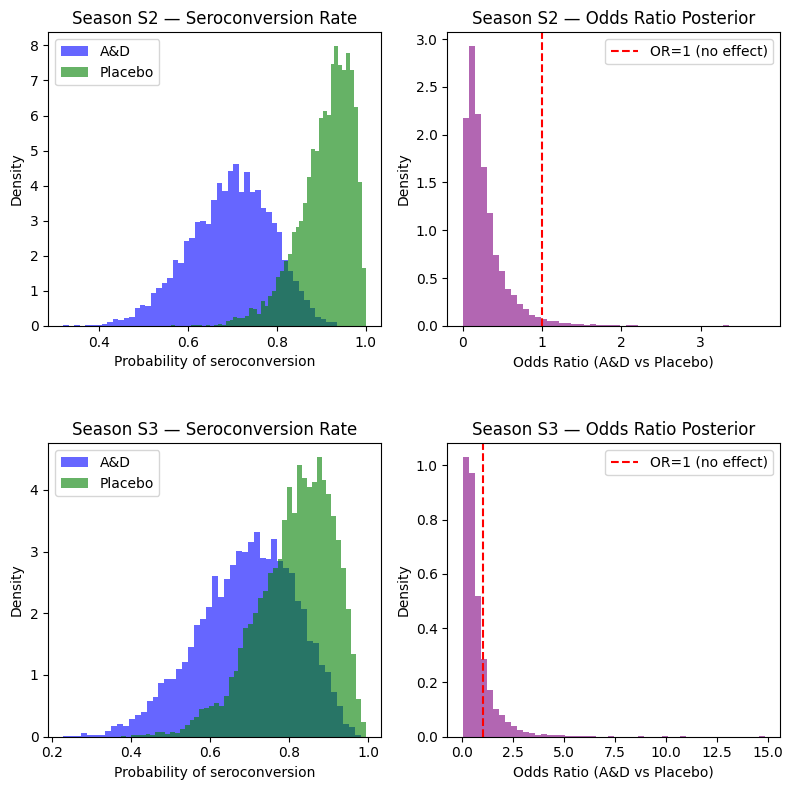

Saved: ../figures/03_bayesian_model.png


In [7]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

for row, season, tr_key, pl_key, or_key in [
    (0, 'S2', 'p_s2_ad', 'p_s2_pl', 'or_s2'),
    (1, 'S3', 'p_s3_ad', 'p_s3_pl', 'or_s3'),
]:
    samples_ad = trace_uninformative.posterior[tr_key].values.flatten()
    samples_pl = trace_uninformative.posterior[pl_key].values.flatten()
    ax[row, 0].hist(samples_ad, bins=50, density=True, color='blue',   alpha=0.6, label='A&D')
    ax[row, 0].hist(samples_pl, bins=50, density=True, color='green',  alpha=0.6, label='Placebo')
    ax[row, 0].set_title(f"Season {season} — Seroconversion Rate")
    ax[row, 0].set_xlabel("Probability of seroconversion")
    ax[row, 0].set_ylabel("Density")
    ax[row, 0].legend()

    samples_or = trace_uninformative.posterior[or_key].values.flatten()
    ax[row, 1].hist(samples_or, bins=50, density=True, color='purple', alpha=0.6)
    ax[row, 1].axvline(x=1.0, color='red', linestyle='--', label='OR=1 (no effect)')
    ax[row, 1].set_title(f"Season {season} — Odds Ratio Posterior")
    ax[row, 1].set_xlabel("Odds Ratio (A&D vs Placebo)")
    ax[row, 1].set_ylabel("Density")
    ax[row, 1].legend()

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.savefig('../figures/03_bayesian_model.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../figures/03_bayesian_model.png")

## Section 7: Forest Plot — Posterior ORs by Season and Prior

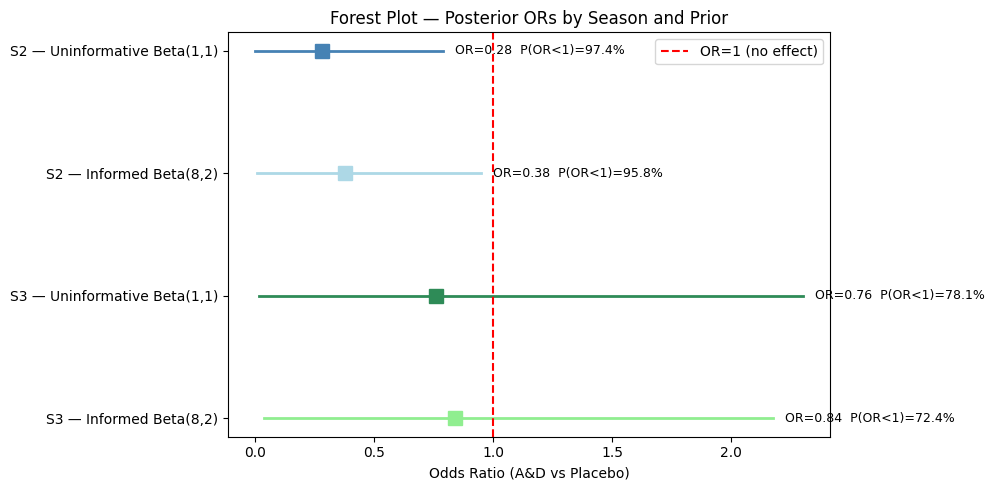

Saved: ../figures/03_bayesian_model_forest_plot.png


In [8]:
or_s2_mean_u = trace_uninformative.posterior["or_s2"].values.mean()
or_s3_mean_u = trace_uninformative.posterior["or_s3"].values.mean()
or_s2_mean_i = trace_informative.posterior["or_s2"].values.mean()
or_s3_mean_i = trace_informative.posterior["or_s3"].values.mean()

rows = [
    (or_s2_mean_u, hdi_s2_u, p_or_s2),
    (or_s2_mean_i, hdi_s2_i, p_or_s2_informed),
    (or_s3_mean_u, hdi_s3_u, p_or_s3),
    (or_s3_mean_i, hdi_s3_i, p_or_s3_informed),
]
labels  = ["S2 — Uninformative Beta(1,1)", "S2 — Informed Beta(8,2)",
           "S3 — Uninformative Beta(1,1)", "S3 — Informed Beta(8,2)"]
colors  = ['steelblue', 'lightblue', 'seagreen', 'lightgreen']
y_pos   = [4, 3, 2, 1]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mean, hdi, p) in enumerate(rows):
    y = y_pos[i]
    ax.plot([hdi[0], hdi[1]], [y, y], color=colors[i], linewidth=2)
    ax.plot(mean, y, marker='s', color=colors[i], markersize=10)
    ax.text(hdi[1] + 0.05, y, f"OR={mean:.2f}  P(OR<1)={p:.1%}", va='center', fontsize=9)

ax.axvline(x=1.0, color='red', linestyle='--', label='OR=1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds Ratio (A&D vs Placebo)")
ax.set_title("Forest Plot — Posterior ORs by Season and Prior")
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_bayesian_model_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: ../figures/03_bayesian_model_forest_plot.png")

## Section 8: Conclusion

In [9]:
print("CONCLUSION")
print("=" * 60)
lines = [
    "CONCLUSION",
    "=" * 60,
    f"  S2 — Uninformative: P(OR<1) = {p_or_s2:.1%}",
    f"  S2 — Informed:      P(OR<1) = {p_or_s2_informed:.1%}",
    f"  S3 — Uninformative: P(OR<1) = {p_or_s3:.1%}",
    f"  S3 — Informed:      P(OR<1) = {p_or_s3_informed:.1%}",
    "",
    "Frequentist: p > 0.30 for both seasons — 'not significant'",
    "Bayesian: both seasons show >60% probability A&D reduces seroconversion.",
    "Results are robust across prior choices.",
    "With n=11-21 per group, a larger trial is warranted.",
]
print("\n".join(lines))

CONCLUSION
CONCLUSION
  S2 — Uninformative: P(OR<1) = 97.4%
  S2 — Informed:      P(OR<1) = 95.8%
  S3 — Uninformative: P(OR<1) = 78.1%
  S3 — Informed:      P(OR<1) = 72.4%

Frequentist: p > 0.30 for both seasons — 'not significant'
Bayesian: both seasons show >60% probability A&D reduces seroconversion.
Results are robust across prior choices.
With n=11-21 per group, a larger trial is warranted.
